# Credit Risk Decision Engine — Baseline Model

This notebook establishes a baseline credit-risk model using Logistic Regression.

### Objectives

- Create a stratified train-validation split
- Build leakage-safe preprocessing pipelines
- Handle missing numerical and categorical values
- Encode categorical variables
- Scale numerical variables
- Train a Logistic Regression baseline
- Evaluate predicted probability of payment difficulty
- Compare raw features against engineered features
- Establish baseline metrics for future tree-based models

### Primary Metrics

Because the dataset is highly imbalanced, model quality will primarily be evaluated using:

- ROC-AUC
- PR-AUC / Average Precision
- Precision
- Recall
- F1 Score

Accuracy will be reported only for context.

Imports

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 150)

PROJECT_ROOT

WindowsPath('d:/Credit-Risk-Decision-Engine')

Load the dataset

In [5]:
from src.components.data_loader import load_training_data
from src.components.feature_engineering import create_features

In [6]:
df = load_training_data()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 307,511
Columns: 122


In [7]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Define target and ID

In [8]:
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

Separate X and y

In [9]:
X = df.drop(
    columns=[TARGET_COLUMN]
)

y = df[TARGET_COLUMN]

In [10]:
print(X.shape)
print(y.shape)

(307511, 121)
(307511,)


In [11]:
y.value_counts(
    normalize=True
).mul(100).round(2)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Stratified train-validation split

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.20, random_state=42, stratify=y)

In [13]:
print("Training distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nValidation distribution:")
print(
    y_valid
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Validation distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


Majority-class benchmark

In [14]:
majority_predictions = np.zeros(
    len(y_valid),
    dtype=int
)

majority_accuracy = accuracy_score(
    y_valid,
    majority_predictions
)

print(
    f"Always predict non-default accuracy: "
    f"{majority_accuracy:.4f}"
)

Always predict non-default accuracy: 0.9193


# Model 1 — Raw features

First establish the baseline without engineered features.

In [15]:
X_train_raw = X_train.drop(
    columns=[ID_COLUMN]
)

X_valid_raw = X_valid.drop(
    columns=[ID_COLUMN]
)

Detect numeric and categorical columns

In [16]:
numeric_columns_raw = (
    X_train_raw
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns_raw = (
    X_train_raw
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print(
    f"Numeric columns: {len(numeric_columns_raw)}"
)

print(
    f"Categorical columns: {len(categorical_columns_raw)}"
)

Numeric columns: 104
Categorical columns: 16


# Preprocessing helper

Instead of writing the preprocessing logic twice, make a small notebook helper

In [17]:
def build_preprocessor(
    numeric_columns,
    categorical_columns
):

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_columns
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns
            )
        ]
    )

Raw model pipeline

In [18]:
raw_preprocessor = build_preprocessor(
    numeric_columns_raw,
    categorical_columns_raw
)

In [19]:
raw_model = Pipeline(
    steps=[
        (
            "preprocessor",
            raw_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [20]:
raw_model.fit(
    X_train_raw,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](120,)","['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',..., 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,120
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedco

Raw-model probabilities

In [21]:
raw_probabilities = (
    raw_model
    .predict_proba(
        X_valid_raw
    )[:, 1]
)

Reusable evaluation helper

In [22]:
def evaluate_model(
    y_true,
    probabilities,
    threshold=0.50
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    return pd.Series(
        {
            "Accuracy": accuracy_score(
                y_true,
                predictions
            ),

            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

            "F1": f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

            "ROC_AUC": roc_auc_score(
                y_true,
                probabilities
            ),

            "PR_AUC": average_precision_score(
                y_true,
                probabilities
            )
        }
    )

In [23]:
raw_metrics = evaluate_model(
    y_valid,
    raw_probabilities
)

raw_metrics

Accuracy     0.919516
Precision    0.571429
Recall       0.012085
F1           0.023669
ROC_AUC      0.748310
PR_AUC       0.227914
dtype: float64

Model 2 — Engineered features

Apply feature_engineering.py

In [24]:
X_train_engineered = create_features(
    X_train
)

X_valid_engineered = create_features(
    X_valid
)

Check new shape

In [25]:
print(
    "Raw train shape:",
    X_train.shape
)

print(
    "Engineered train shape:",
    X_train_engineered.shape
)

Raw train shape: (246008, 121)
Engineered train shape: (246008, 143)


Verify new features exist

In [26]:
engineered_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_AGE_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "EXT_SOURCE_MEAN",
    "DOCUMENT_COUNT"
]

[
    feature
    for feature in engineered_features
    if feature in X_train_engineered.columns
]

['AGE_YEARS',
 'EMPLOYMENT_YEARS',
 'EMPLOYMENT_AGE_RATIO',
 'CREDIT_INCOME_RATIO',
 'ANNUITY_INCOME_RATIO',
 'CREDIT_ANNUITY_RATIO',
 'EXT_SOURCE_MEAN',
 'DOCUMENT_COUNT']

Drop ID and original employment anomaly

In [27]:
X_train_engineered = (
    X_train_engineered
    .drop(
        columns=[
            ID_COLUMN,
            "DAYS_EMPLOYED"
        ],
        errors="ignore"
    )
)

X_valid_engineered = (
    X_valid_engineered
    .drop(
        columns=[
            ID_COLUMN,
            "DAYS_EMPLOYED"
        ],
        errors="ignore"
    )
)

Identify feature types

In [28]:
numeric_columns_engineered = (
    X_train_engineered
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns_engineered = (
    X_train_engineered
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print(
    f"Numeric features: "
    f"{len(numeric_columns_engineered)}"
)

print(
    f"Categorical features: "
    f"{len(categorical_columns_engineered)}"
)

Numeric features: 125
Categorical features: 16


Engineered preprocessing

In [29]:
engineered_preprocessor = build_preprocessor(
    numeric_columns_engineered,
    categorical_columns_engineered
)

Engineered Logistic Regression

In [30]:
engineered_model = Pipeline(
    steps=[
        (
            "preprocessor",
            engineered_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [31]:
engineered_model.fit(
    X_train_engineered,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](141,)","['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',...,'CONTACT_COUNT', 'DEF_30_SOCIAL_RATIO','DEF_60_SOCIAL_RATIO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,141
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

Predict probabilities

In [32]:
engineered_probabilities = (
    engineered_model
    .predict_proba(
        X_valid_engineered
    )[:, 1]
)

In [33]:
engineered_metrics = evaluate_model(
    y_valid,
    engineered_probabilities
)

engineered_metrics

Accuracy     0.919662
Precision    0.639535
Recall       0.011078
F1           0.021778
ROC_AUC      0.751194
PR_AUC       0.236486
dtype: float64

Raw vs engineered comparison

In [34]:
model_comparison = pd.DataFrame(
    {
        "Raw Logistic Regression":
            raw_metrics,

        "Engineered Logistic Regression":
            engineered_metrics
    }
).T

model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Raw Logistic Regression,0.919516,0.571429,0.012085,0.023669,0.748310,0.227914
Engineered Logistic Regression,0.919662,0.639535,0.011078,0.021778,0.751194,0.236486


In [35]:
print(
    "ROC-AUC change:",
    engineered_metrics["ROC_AUC"]
    - raw_metrics["ROC_AUC"]
)

print(
    "PR-AUC change:",
    engineered_metrics["PR_AUC"]
    - raw_metrics["PR_AUC"]
)

ROC-AUC change: 0.0028840818838807847
PR-AUC change: 0.008571421453193284


Classification report

In [36]:
engineered_predictions = (
    engineered_probabilities >= 0.50
).astype(int)

In [37]:
print(
    classification_report(
        y_valid,
        engineered_predictions,
        target_names=[
            "Non-Default",
            "Payment Difficulty"
        ]
    )
)

                    precision    recall  f1-score   support

       Non-Default       0.92      1.00      0.96     56538
Payment Difficulty       0.64      0.01      0.02      4965

          accuracy                           0.92     61503
         macro avg       0.78      0.51      0.49     61503
      weighted avg       0.90      0.92      0.88     61503



Confusion matrix

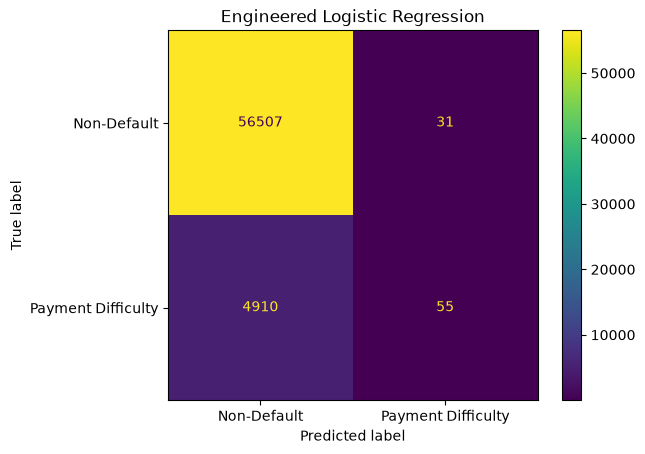

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    engineered_predictions,
    display_labels=[
        "Non-Default",
        "Payment Difficulty"
    ]
)

plt.title(
    "Engineered Logistic Regression"
)

plt.show()

ROC curve

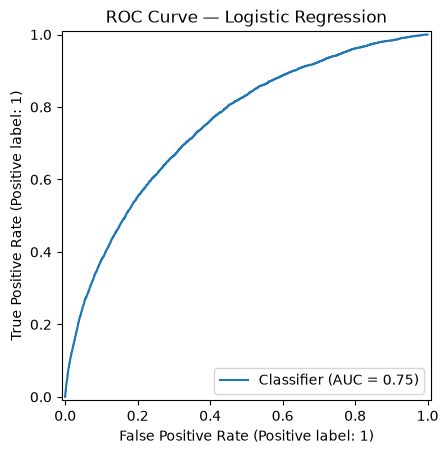

In [39]:
RocCurveDisplay.from_predictions(
    y_valid,
    engineered_probabilities
)

plt.title(
    "ROC Curve — Logistic Regression"
)

plt.show()

Precision-Recall curve

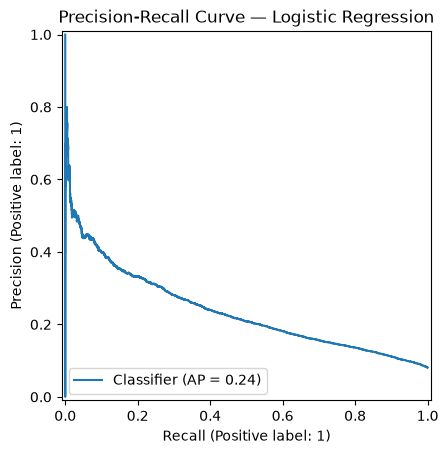

In [40]:
PrecisionRecallDisplay.from_predictions(
    y_valid,
    engineered_probabilities
)

plt.title(
    "Precision-Recall Curve — Logistic Regression"
)

plt.show()

Probability distribution

In [41]:
probability_df = pd.DataFrame(
    {
        "probability":
            engineered_probabilities,

        "TARGET":
            y_valid.values
    }
)

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    probability_df.loc[
        probability_df["TARGET"] == 0,
        "probability"
    ],
    bins=50,
    alpha=0.6,
    density=True,
    label="Non-Default"
)

plt.hist(
    probability_df.loc[
        probability_df["TARGET"] == 1,
        "probability"
    ],
    bins=50,
    alpha=0.6,
    density=True,
    label="Payment Difficulty"
)

plt.xlabel(
    "Predicted Probability of Payment Difficulty"
)

plt.ylabel("Density")

plt.title(
    "Predicted Risk Distribution"
)

plt.legend()

plt.show()